# Week 11: Assignment 4 - Logistic Regression Assignment (Age & Salary → Purchased)
**Coures:** INFO 4670 Fengjiao Tu  
**Goal:** Train and evaluate a Logistic Regression model to predict whether a customer purchases a car using `Age` and `Salary`.

---

## I. Assignment Objective
By completing this assignment, you will:
- Understand the concept and intuition of logistic regression.
- Load and preprocess data using `pandas`.
- Train and evaluate a logistic regression model with `scikit-learn`.
- Visualize classification results.
- Analyze model performance and reflect on possible improvements.


## II. Dataset Description
Expected CSV file name: **`car_purchase_data.csv`**

| Column | Description | Example |
|--------|-------------|---------|
| `Age` | Age of the customer | 35 |
| `Salary` | Annual or monthly income | 60000 |
| `Purchased` | Whether the customer purchased a car (1 = Yes, 0 = No) | 1 |


---
# Grading Rubric (Total = 100 points)

| Section | Description | Points | Details |
|--------|-------------|--------|---------|
| **Objective Understanding** | Explain purpose and logic of logistic regression | 10 | Goal & rationale (5); why LR for this task (5) |
| **Data Preparation** | Data loading, splitting, scaling | 20 | Import & preview (5); X/y split (5); train/test (5); scaling (5) |
| ** Model Training & Evaluation** | Fit, predict, metrics, visualization | 40 | Trained correctly (10); metrics shown (10); **accuracy ≥ 87.5% (10)**; visualization (10) |
| ** Analysis & Reflection** | Interpretation and critical thinking | 30 | Probability→class explanation (10); result discussion (10); improvements (10) |


**Accuracy Requirement:**
- Full credit (10 pts) if **accuracy ≥ 87.5%**
- Partial (7–9 pts) if **80% ≤ accuracy < 87.5%**
- Minimal (≤5 pts) if **accuracy < 80%**
- 0 pts if the model fails to run


## III. Steps to Complete
Follow the cells below in order. According to the hands-on task, please complete the code.

### Step 1: Import libraries and load data

In [2]:
#Please write the code here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv('car_purchase_data.csv')
df.head(10)

,User ID,Gender,Age,Salary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
5,15728773,Male,27,58000,0
6,15598044,Female,27,84000,0
7,15694829,Female,32,150000,1
8,15600575,Male,25,33000,0
9,15727311,Female,35,65000,0


### Step 2: Split features and target

In [5]:
#Please write the code here
X = df[['Age', 'Salary']].values
y = df['Purchased'].values
print("Feature matrix X shape:", X.shape)
print("Target vector y shape: ", y.shape)
print("Class distribution — 0 (No):", (y == 0).sum(),
      " | 1 (Yes):", (y == 1).sum())

Feature matrix X shape: (400, 2)
Target vector y shape:  (400,)
Class distribution — 0 (No): 257  | 1 (Yes): 143


### Step 3: Train/Test Split

In [6]:
#Please write the code here
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=0
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")

Training samples : 320
Test samples     : 80


### Step 4: Feature Scaling

In [7]:
#Please write the code here
sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc  = sc.transform(X_test)

print("Training set — Mean (should be ~0):", X_train_sc.mean(axis=0).round(4))
print("Training set — Std  (should be ~1):", X_train_sc.std(axis=0).round(4))

Training set — Mean (should be ~0): [0. 0.]
Training set — Std  (should be ~1): [1. 1.]


### Step 5: Train Logistic Regression Model

In [8]:
#Please write the code here
classifier = LogisticRegression(random_state=42)
classifier.fit(X_train_sc, y_train)

print("Model trained successfully!")
print(f"Intercept  : {classifier.intercept_[0]:.4f}")
print(f"Coefficient (Age)    : {classifier.coef_[0][0]:.4f}")
print(f"Coefficient (Salary) : {classifier.coef_[0][1]:.4f}")

Model trained successfully!
Intercept  : -0.8707
Coefficient (Age)    : 2.0032
Coefficient (Salary) : 1.0807


### Step 6: Predict and Evaluate

Test Accuracy: 0.9250  (92.50%)

Classification Report:
               precision    recall  f1-score   support

Not Purchased       0.92      0.98      0.95        58
    Purchased       0.94      0.77      0.85        22

     accuracy                           0.93        80
    macro avg       0.93      0.88      0.90        80
 weighted avg       0.93      0.93      0.92        80



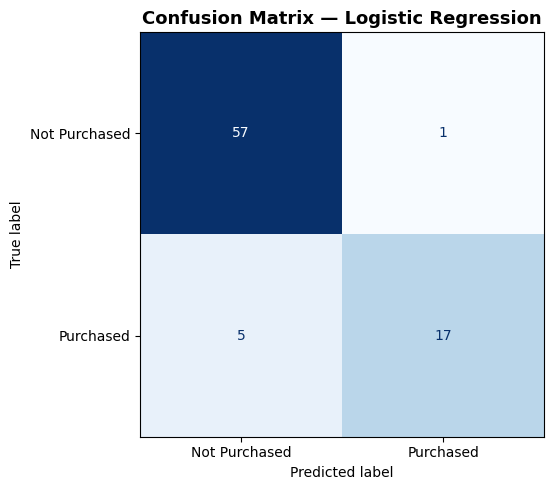

In [10]:
#Please write the code here
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

y_pred = classifier.predict(X_test_sc)

#Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.4f}  ({acc*100:.2f}%)")
print()

#Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Purchased', 'Purchased']))

#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Purchased', 'Purchased'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Logistic Regression', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Step 7: Visualization of Decision Regions

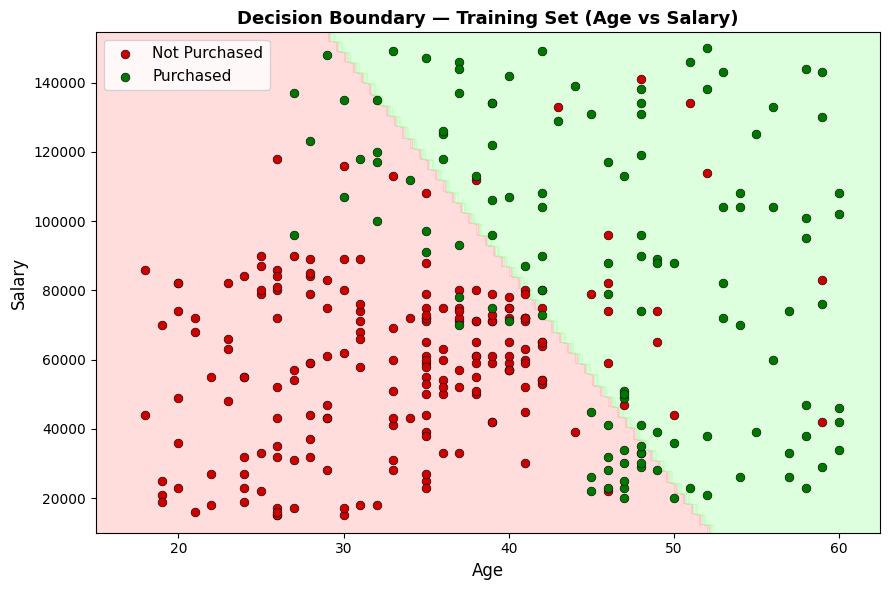

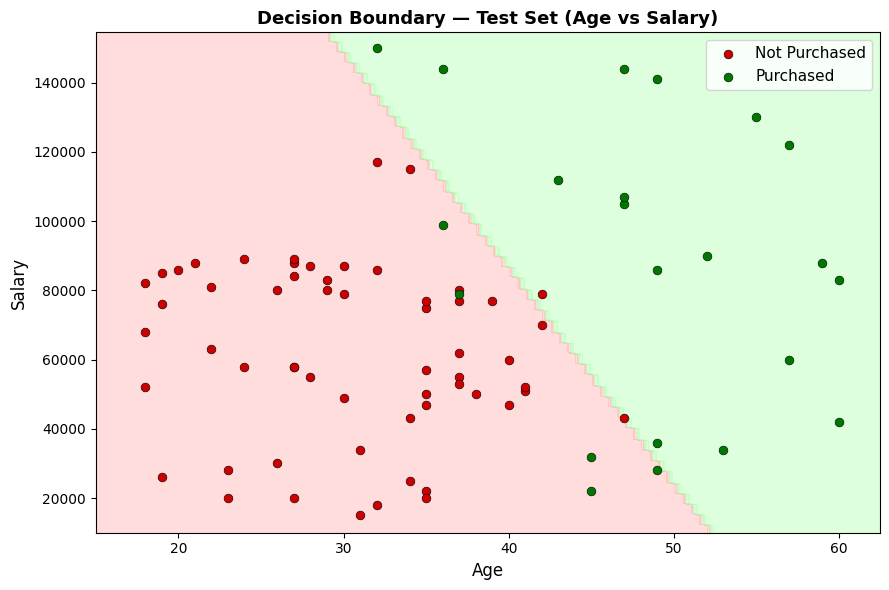

In [11]:
#Please write the code here
from matplotlib.colors import ListedColormap

def plot_decision_regions(X_set, y_set, classifier, scaler, title):
    #Build a mesh in original feature space
    age_min, age_max = X_set[:, 0].min() - 3,  X_set[:, 0].max() + 3
    sal_min, sal_max = X_set[:, 1].min() - 5000, X_set[:, 1].max() + 5000

    age_grid = np.arange(age_min, age_max, 0.5)
    sal_grid = np.arange(sal_min, sal_max, 500)
    xx, yy = np.meshgrid(age_grid, sal_grid)

    #Scale the mesh before predicting
    mesh_scaled = scaler.transform(np.c_[xx.ravel(), yy.ravel()])
    Z = classifier.predict(mesh_scaled).reshape(xx.shape)

    #Colors
    bg_cmap = ListedColormap(['#FFAAAA', '#AAFFAA'])
    dot_colors = ['#CC0000', '#007700']

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.contourf(xx, yy, Z, alpha=0.4, cmap=bg_cmap)

    for cls, color, label in zip([0, 1], dot_colors, ['Not Purchased', 'Purchased']):
        mask = y_set == cls
        ax.scatter(X_set[mask, 0], X_set[mask, 1], c=color, s=40, edgecolors='k', linewidths=0.4, label=label, zorder=3)

    ax.set_xlabel('Age', fontsize=12)
    ax.set_ylabel('Salary', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

#Training set
plot_decision_regions(
    X_train, y_train, classifier, sc, title='Decision Boundary — Training Set (Age vs Salary)'
)

#Test set
plot_decision_regions(
    X_test, y_test, classifier, sc, title='Decision Boundary — Test Set (Age vs Salary)'
)

## IV. Reflection Questions
1. Logistic regression outputs probabilities — why can it still be used for classification?
2. Based on your model, which customers are more likely to purchase a car?
3. What factors might cause low accuracy in this task?
4. Propose additional features or preprocessing steps that could improve accuracy.


#Please write your answer here

1.Logistic regression uses the Sigmoid function to output a probability between 0 and 1 and to turn that into something that can be used for classification, there is a threshold of .5. If the probability is higher than .5, then you can see that the model predicts Purchased whereas if the probability is lower than .5 the model predicts Not Purchased. So, this is what allows a probability output to make classification decisions.

2.Based on my model, I would say that customer that are older, like above the age of 40, or customers that have a salary over $80000 are more likely to purchase a car. From my data, age was the strongest predictor with a coefficient of 2 which means that it had about twice the influence of salary.

3.I think that one of the factors that might cause low accuracy in this task is that the data has an overlap zone for middle aged people and moderate salaries that a straight line cannot perfectly separate. I think another factor could be that we only used age and salary when there are other important factors that are missing from the dataset.

4.I think something we could do is add a gender column which would add an extra signal that our model ignores right now. We could also add polynomial features which would allow the model to fit a curved boundary instead of just the straight line which might be better for separating the overlapping classes.